# **1. 손글씨 도형 분류하기**
- 손으로 그린 원, 삼각형, X 이미지를 CNN으로 분류
- 데이터 구성: 학습 데이터 240장, 테스트 60장, 3개의 클래스가 균등하게 구성

In [1]:
import os
import random
import torch
import torch.nn as nn
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

In [2]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
extract_dir = Path("./data")
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# 압축 풀기
with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
    zip_ref.extractall(extract_dir)

In [5]:
shape_root = extract_dir / 'shape'
train_dir = shape_root / 'train'
test_dir = shape_root / 'test'
print('Train Directory: ', train_dir)
print('Test Directory: ',test_dir)

Train Directory:  data\shape\train
Test Directory:  data\shape\test


### ImageFolder
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서대로 클래스 번호를 지정함

In [6]:
# data/shape/train -> cir(0), tri(1), x(2)
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)
print('Class: ', raw_train.classes)
print('Class Num: ', raw_train.class_to_idx)
print('Train Data Image Num: ', len(raw_train))
print('Test Data Image Num: ', len(raw_test))

Class:  ['cir', 'tri', 'x']
Class Num:  {'cir': 0, 'tri': 1, 'x': 2}
Train Data Image Num:  240
Test Data Image Num:  60


# **2. 전처리와 데이터 증강**
- Info: 배경을 검은색으로 바꾸는게 효과적이고 성능 높아짐 (흰: 255, 검: 0)
- 모든 이미지를 28*28 1채널 흑백으로 통일함
- 흰 배경에 검은 선으로 그려진 이미지를 반전하여 선 부분이 큰 값을 갖게 함
- 픽셀 값을 텐서로 바꾼 뒤, 평균 0.5, 표준편차 0.5로 정규화
- 학습 데이터에만 작은 회전/이동/크기 변화를 적용. 일반화 성능을 높임

In [7]:
# Train용 transform
# Compose: 리스트 안의 변화들을 '순서대로' 변화시킴
train_transform = transforms.Compose([
    transforms.Resize((28, 28)), 
    transforms.Grayscale(num_output_channels=1),  # Grayscale로 변환
    transforms.RandomInvert(p=1.0), # 모든 이미지를 반전
    transforms.RandomAffine(
        degrees=12,  
        translate=(0.08, 0.08),  # x, y 축으로 랜덤하게 이동
        scale=(0.90, 1.10), # 크기 조정
    ),
    transforms.ToTensor(), # 한 픽셀당 0~255 색상 값을 0~1 사이의 값으로 변환

    # transforms.ToTensor()를 거쳐 0~1사이로 바뀐 픽셀 값에 (값-0.5) / 0.5 공식을 적용해 중앙값을 0, 범위를 -1~1로 조절 -> 인공지능 모델이 더 빠르고 안정적으로 학습할 수 있게 함
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# 테스트용 transform
eval_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# 3. **학습/검증/테스트 데이터 분리**
- 학습 데이터: 가중치를 실제로 업데이트 함
- 검증 데이터: 학습 중 모델 선택과 과적합 확인에 사용
- 테스트 데이터: 모든 학습과 모델 선택이 끝난 뒤, 최종 성능을 확인

In [8]:
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
num_classes

3

In [9]:
train_indices = []
val_indices = []
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx)[0]
    rng.shuffle(indices)
    split = int(len(indices) * 0.8)
    train_indices.extend(indices[:split].tolist())  # 첫 80프로 train_indices
    val_indices.extend(indices[split:].tolist())  # 나머지 20프로 val_indices

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
val_full = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# 기존 데이터셋에서 원하는 데이터만 선택하여 새로운 데이터셋을 만듦
train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

print('Train: ', len(train_dataset))
print('Val: ', len(val_dataset))
print('Test: ', len(test_dataset))


Train:  192
Val:  48
Test:  60


In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0, # CPU 다 써라
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# **4. 이미지와 텐서 모양 확인**
- CNN 입력 텐서는 [배치, 채널(흑백=1, 컬러=3), 높이, 너비] 순서
- 현재 위 데이터의 한 배치의 shape는 [32, 1, 28, 28]

In [11]:
images, labels = next(iter(train_loader))  # 32개 이미지와 32개 라벨
print('image batch: ', images.shape)
print('label batch: ', labels.shape)

image batch:  torch.Size([32, 1, 28, 28])
label batch:  torch.Size([32])


In [12]:
def denormalize(image):
    return image * 0.5 + 0.5

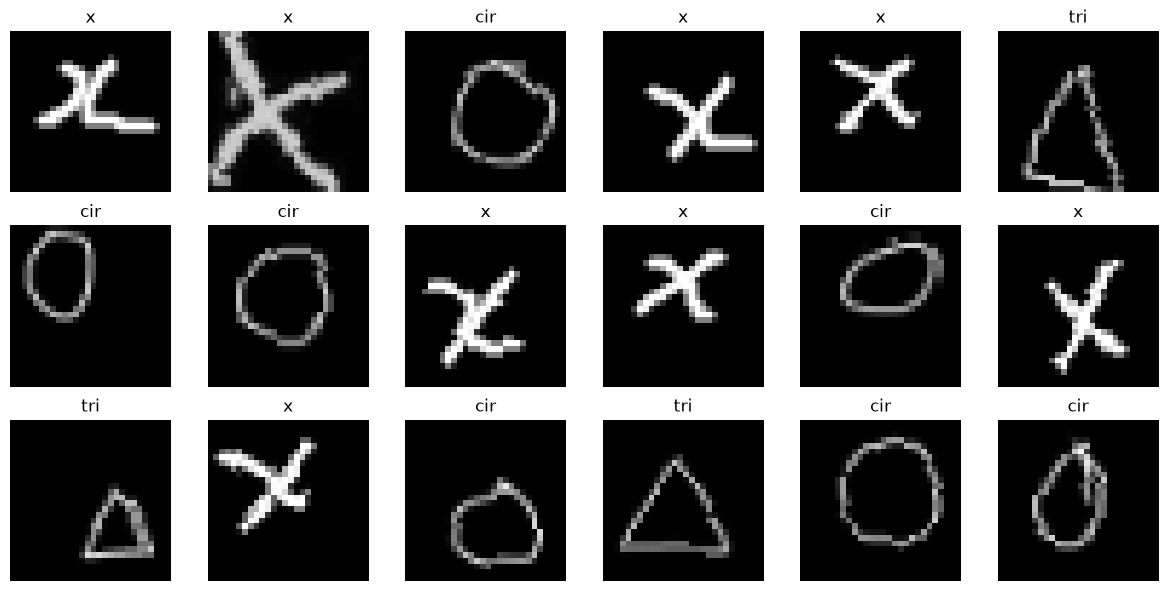

In [13]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1)  # squeeze(0): 0번 자리에 있는 채널이 1이면 없애주기 >> (28*28)을 grayscale로 변환
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

# **5. CNN 모델**


### Feature Map의 증가
```
1 > 28 > 28 > MaxPool
28 > 56 > 56 > MaxPool
```
- 입력 이미지는 흑백 이미지이므로 처음에는 채널이 1개
- 첫 번째 합성곱층에서는 28개의 커널이 서로 다른 특징을 학습 
  - (예: 가로선, 세로선, 대각선, 곡선, 모서리, 원의 경계, 삼각형의 꼭짓점, X의 교차점과 같은 다양한 특징을 각각 학습하게 됨)
  - 즉 입력 이미지 한 장을 하나의 특징으로 보는 것이 아니라 28개의 서로 다른 특징 맵으로 표현하게 됨
- 뒤로 갈수록 채널 수를 늘리는 이유:
  - 뒤쪽 레이어는 앞에서 학습한 특징들을 다시 조합하여 더 복잡한 특징을 찾음

### Dropout
- 학습할 때 일부 뉴런을 무작위로 비활성화 하여 과적합을 방지하는 기법
- 예) 뉴런이 100개라면 약 25개는 사용하지 않고, 약 75개만 이용하여 학습함
- 매 학습마다 비활성화되는 뉴런이 랜덤하게 달라지므로 특정 뉴런 하나에만 의존하지 않고 여러 특징을 함께 학습할 수 있게 됨.

### BatchNorm2d
- 합성곱 층의 출력값을 적절한 범위로 정규화하여 학습을 더 빠르고 안정적으로 만들어주는 층
- 예)
```
채널1 출력 [5, 9, 8, 7] > 범위 5 ~ 9
채널2 출력 [120, 140, 156, 134] > 범위 120 ~ 156
채널3 출력 [-80, -90, -130, -30] > 범위 -130 ~ -30
...
채널 32 출력 [1, 3, 5, 10] > 범위 1 ~ 10
```
- 각 채널마다 값의 범위가 다르기 때문에(다른 kernel 사용) 레이어가 학습하기 어려움
- BatchNorm은 각 채널마다 평균(0 부근), 분산(1 정도)을 계산하여 범위를 일정하게 만듦
- 학습이 빨라짐 (Loss가 더 빨리 감소)
- 값이 너무 커지거나 작아지는 현상 줄어듦

### AdaptiveAvgPool2d
- 입력 이미지의 크기가 얼마이든 상관 없이 최종 출력 크기를 항상 특정 크기로 만들어주는 평균 풀링 레이어
- CNN에서 분류 모델의 마지막 부분에 매우 자주 사용
- 예) nn.AdaptiveAvgPool2d((1, 1))라면 입력 64x64일 때, 32x32 모두 출력 1x1
  ```
  5 7 6
  8 9 2
  1 3 4
  sum(5, 7, 6, 8, 9, 2, 1, 3, 4) / 9 = 5
  ```
- CNN의 마지막에는 보통 128*7*7 같은 Feautre Map이 있음. 이 것을 Fully Connected Layer에 넣으려면 1차원으로 바꿔야 함
- Flatten 시켜서 계산하는 것과 동일
  - linear(6272, 1000)  >> 6272개의 데이터를 1000개의 클래스로 내보내겠다
  - linear(6272, 1000) >> 가중치 6272*1000 = 6272000 개
- AdaptiveAvgPool2d 계산 후 파라미터가 줄었기 때문에 linear(128, 1000) = 128000 개

In [14]:
class ShapeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()  # super() 메소드: 부모 클래스의 생성자를 호출

        # layer 쌓기
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),  # 이미지 1개, 32개의 feature, kernel 3x3, padding 상하좌우 1씩, bias 없이
            nn.BatchNorm2d(32),  # 출력값 정규화
            nn.ReLU(inplace=True), # 비선형화
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),  # 이미지 32개, 32개의 feature, ...
            nn.BatchNorm2d(32),  # 출력값 정규화
            nn.ReLU(inplace=True), # 비선형화

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),  
            nn.ReLU(inplace=True),  
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),  
            nn.ReLU(inplace=True),          

            nn.MaxPool2d(kernel_size=2),
        ) 
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # 2d로 만들어 주고
            nn.Flatten(),  # 일렬로 만들어주고
            nn.Dropout(p=0.25),  # 1/4를 껐다 켰다 반복 하며 학습
            nn.Linear(64, num_classes)  # 64개를 가져와서 3개의 클래스로 반환
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

### CUDA & NVIDIA 드라이버 확인
- 최신 드라이버와 CUDA Toolkit 설치 권장
- 드라이버 버전 확인
- CUDA Version이 11.x 또는 12.x로 나오면 OK

### Pytorch 설치 (CUDA 지원)
- 공식 사이트에서 명령어 생성
- https://pytorch.org/get-started/locally/
- pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu130 복사 후 실행

In [15]:
print(torch.__version__)              # 설치된 버전 확인
print(torch.cuda.is_available())      # True면 GPU 사용 가능
print(torch.cuda.get_device_name(0))

2.14.0+cu132
True
NVIDIA GeForce RTX 5060 Laptop GPU


In [16]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [18]:
model = ShapeCNN(num_classes=num_classes).to(device)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

### Adam
- 학습률을 자동으로 조절해 주는 최적화 알고리즘
### AdamW
- Adam에 가중치 감쇠(Weight Decay)를 적용한 방식
- 딥러닝 모델의 가중치가 지나치게 커지면 학습 데이터에 너무 맞춰지는 과적합이 발생할 수 있음
- Weight Decay는 학습 중에 가중치를 조금씩 줄여서 너무 커지지 않도록 하는 방법


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# 검증 성능이 더 이상 좋아지지 않을 때 자동으로 학습률을 낮춰주는 Scheduler
# 가중치 = 가중치 - 학습률 * 기울기
# 학습률은 얼마나 크게 움직일지를 결정 예) lr=0.1 >> 100만큼 이동해야 하면 10만큼만 이동
# 학습 초반에는 빠르게 내려가는것이 좋음 > 후반부에는 거의 최적값 근처에 도착하기 때문에 최적점을 지나치지 않기 위해 보폭을 줄여줌
# Epoch: Loss > 0.8 > 0.6 > 0.5 > 0.43 > 0.40 > 0.40 > 0.40
scheduler = optim.lr_scheduler.ReduceLROnPlateau(  # "성능이 좋아지지 않으면 learning rate를 줄여라"
    optimizer, 
    mode='min', # 무엇을 기준으로 좋아졌다고 판단할지를 결정
    factor=0.5, # 학습률을 절반으로 줄임
    patience=3  # 몇 번까지 참아줄 것인지 설정
)

### 학습과 평가 함수

In [20]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    is_training = optimizer is not None  # optimizer가 기울기를 조정 해주기 때문에 optimizer가 있으면 학습중

    # train(): dropout, batch normalization등 활성화
    # eval(): 학습된걸 추론
    model.train() if is_training else model.eval()  # 시간, 메모리 절약

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # enable_grad(): 기울기 계산 활성화
    # inference_mode(): 메모리 사용량 감소, 실행 속도 향상, 불필요한 기울기 계산 방지
    context = torch.enable_grad() if is_training else torch.inference_mode()
    with context:
        for images, labels, in loader:
            images = images.to(device, non_blocking=True)  # 비동기적, 병렬로 처리 (GPU면 작동)
            labels = labels.to(device, non_blocking=True)  
            if is_training:
                # 기울기 값을 0으로 채우는 대신 None으로 설정
                # 메모리 사용을 줄일 수 있음, 기울기 초기화 속도가 더 빠름, 불필요한 0 텐서 생성을 줄임
                optimizer.zero_grad(set_to_none=True)
            logits = model(images)  # 학습 중에 해당 기울기를 사용해 계산한 결과값
            loss = criterion(logits, labels)  # 그 결과값과 실제 라벨값(정답)과의 오차

            if is_training:
                loss.backward()  # 역전파
                optimizer.step()  # 기울기 업데이트
            batch_size = labels.size(0)  # 라벨의 개수 = batch size (몇개짜리 묶음인지 알 수 있음)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()  # 제일 높은 확률의 값이 label과 일치하는지 확인 >> 몇개 맞췄는지 저장
            total_samples += batch_size  # sample 크기
    return total_loss / total_samples, total_correct / total_samples  

### 모델 학습과 Eearly Stopping
- 검증 손실이 가장 낮을 때의 가중치를 저장
- 일정 횟수 동안 검증 손실이 개선되지 않으면 학습을 조기에 종료하여 과적합과 불필요한 학습을 출임

In [21]:
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 8  # 8번 이상 개선되지 않으면 학습 종료
best_val_loss = float('inf')  # 양의 무한대수 (최대값)
wait = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_model_path = 'best_shape_cnn.pth'

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, device, optimizer)  # 학습
    val_loss, val_acc = run_epoch(model, val_loader, criterion, device)  # 검증(모의고사)
    scheduler.step(val_loss)  # learning rate 조절

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train loss {train_loss:.4f}, acc {train_acc*100:6.2f}% | '
        f'val loss {val_loss:.4f}, acc {val_acc*100:6.2f}% | '
        f'lr {current_lr:.6f}'
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss  # best_val_loss 검증 오차값 업데이트
        wait = 0  # loss 값이 향상되었기 때문에 patience 0번 적립
        torch.save(model.state_dict(), best_model_path)  # 현재 가중치 가져와서 best_model_path에 저장
    else:
        wait += 1  # patience 1번 적립
        if wait >= EARLY_STOPPING_PATIENCE:  # 8번 이상 적립되면 학습 종료
            print('검증 손실이 더 이상 개선되지 않아 학습을 종료합니다.')
            break

Epoch 01/40 | train loss 0.7920, acc  57.81% | val loss 1.0558, acc  39.58% | lr 0.001000
Epoch 02/40 | train loss 0.5564, acc  72.40% | val loss 0.8911, acc  64.58% | lr 0.001000
Epoch 03/40 | train loss 0.5512, acc  69.27% | val loss 0.7461, acc  77.08% | lr 0.001000
Epoch 04/40 | train loss 0.4788, acc  79.17% | val loss 0.6625, acc  75.00% | lr 0.001000
Epoch 05/40 | train loss 0.4852, acc  78.65% | val loss 0.6063, acc  70.83% | lr 0.001000
Epoch 06/40 | train loss 0.3878, acc  86.98% | val loss 0.5334, acc  83.33% | lr 0.001000
Epoch 07/40 | train loss 0.3670, acc  87.50% | val loss 0.5472, acc  66.67% | lr 0.001000
Epoch 08/40 | train loss 0.3360, acc  90.62% | val loss 0.4095, acc  81.25% | lr 0.001000
Epoch 09/40 | train loss 0.3148, acc  89.58% | val loss 0.4660, acc  77.08% | lr 0.001000
Epoch 10/40 | train loss 0.2629, acc  93.75% | val loss 0.3099, acc  85.42% | lr 0.001000
Epoch 11/40 | train loss 0.2460, acc  93.23% | val loss 0.7411, acc  66.67% | lr 0.001000
Epoch 12/4

### 학습 곡선으로 과적합 확인
- 학습 손실과 검증 손실이 함께 감소하면 정상적인 학습에 가까움
- 학습 손실은 계속 감소하지만 검증 손실이 증가하면 과적합 가능성이 큼
- 학습/검증 정확도가 모두 낮으면 모델 용량, 전처리, 학습률, 데이터 품질등을 점검해야 함

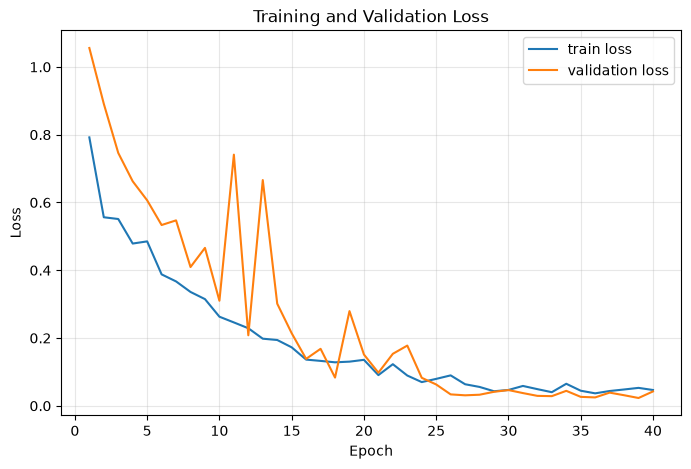

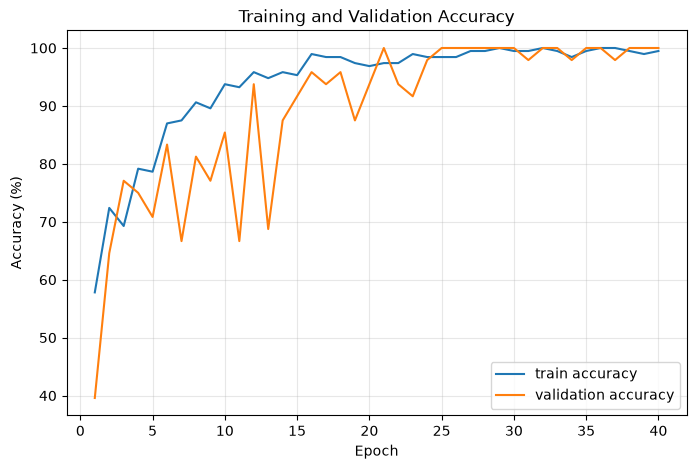

In [22]:
epochs_ran = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history['train_loss'], label='train loss')
plt.plot(epochs_ran, history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, np.array(history['train_acc']) * 100, label='train accuracy')
plt.plot(epochs_ran, np.array(history['val_acc']) * 100, label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 학습된 모델로 테스트 평가

In [23]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, device)
print(f'테스트 손실: {test_loss:.4f}')
print(f'테스트 정확도: {test_acc * 100:.2f}%')

테스트 손실: 0.0301
테스트 정확도: 100.00%


### 학습되지 않은 모델로 테스트 평가

In [24]:
model = ShapeCNN(num_classes=num_classes).to(device)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [25]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, device)
print(f'테스트 손실: {test_loss:.4f}')
print(f'테스트 정확도: {test_acc * 100:.2f}%')

테스트 손실: 1.1001
테스트 정확도: 33.33%


### 가중치를 불러와 모델에 적용한 후 테스트 평가

In [26]:
model = ShapeCNN(num_classes=num_classes).to(device)
model.load_state_dict(torch.load(best_model_path,   # 
                                 map_location=device,  # GPU 사용
                                 weights_only=True))  # 가중치만 불러옴 (모델 전체 X)

<All keys matched successfully>

In [27]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, device)
print(f'테스트 손실: {test_loss:.4f}')
print(f'테스트 정확도: {test_acc * 100:.2f}%')

테스트 손실: 0.0526
테스트 정확도: 98.33%


In [28]:
def collect_predictions(model, loader):
    model.eval()  # 모델을 추론 모드로 바꾸기
    all_images = []
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.inference_mode():  # 테스트 모드
        for images, labels in loader:
            logits = model(images.to(device))
            probs = torch.softmax(logits, dim=1).cpu()
            preds = probs.argmax(dim=1)

            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds)
            all_probs.append(probs)

    return (
        torch.cat(all_images),
        torch.cat(all_labels),
        torch.cat(all_preds),
        torch.cat(all_probs),
    )

In [29]:
test_images, y_true, y_pred, y_prob = collect_predictions(model, test_loader)

### 혼동행렬과 클래스별 성능
- 전체 정확도가 높아도 특정 클래스만 자주 틀릴 수 있음
- 혼동행렬은 실제 클래스와 예측 클래스의 조합을 볼 수 있음
- 대각선 값이 클수록 올바르게 분류한 이미지가 많다는 뜻
- Precision: 해당 클래스로 예측된 것 중 실제로 맞은 비율
- Recall: 실제 해당 클래스 중 모델이 찾아낸 비율
- F1-score: Precision과 Recall의 조화평균

In [30]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

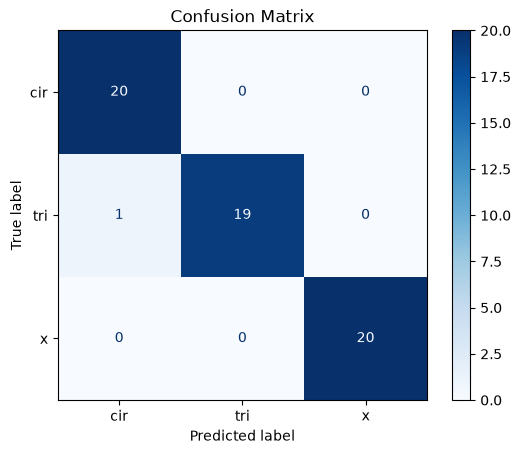

              precision    recall  f1-score   support

         cir     0.9524    1.0000    0.9756        20
         tri     1.0000    0.9500    0.9744        20
           x     1.0000    1.0000    1.0000        20

    accuracy                         0.9833        60
   macro avg     0.9841    0.9833    0.9833        60
weighted avg     0.9841    0.9833    0.9833        60



In [31]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(
    y_true.numpy(),
    y_pred.numpy(),
    target_names=class_names,
    digits=4,
    zero_division=0,
))

### 오분류 이미지 분석
- 모델이 틀린 이미지에는 데이터 품질, 모호한 필기, 전처리 문제, 부족한 학습 데이터 등 중요한 단서가 들어가 있음
- 단순히 정확도 숫자만 보는 것보다 오분류 사례를 직접 확인하는 것이 모델 개선에 매우 중요

In [32]:
wrong_indices = torch.where(y_true != y_pred)[0]
print('오분류 이미지 수: ', len(wrong_indices))

오분류 이미지 수:  1


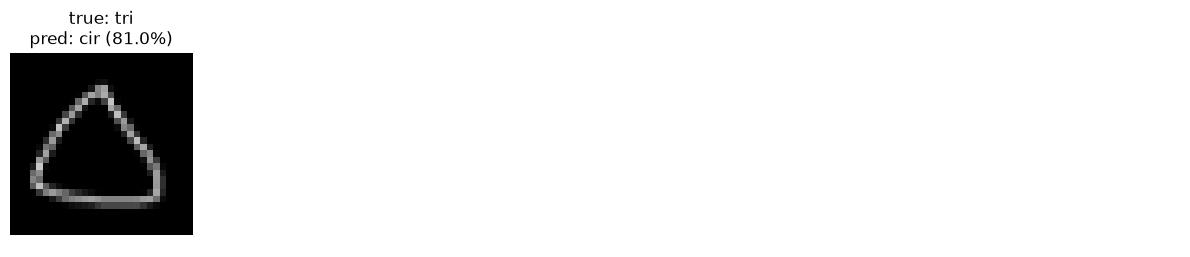

In [35]:
if len(wrong_indices) == 0:
    print('현재 테스트 데이터에서 오분류 이미지가 없습니다.')
else:
    show_count = min(18, len(wrong_indices))
    selected = wrong_indices[:show_count]
    rows = int(np.ceil(show_count / 6))
    fig, axes = plt.subplots(rows, 6, figsize=(12, 2.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, selected):
        true_idx = y_true[idx].item()
        pred_idx = y_pred[idx].item()
        confidence = y_prob[idx, pred_idx].item() * 100
        ax.imshow(denormalize(test_images[idx]).squeeze(0), cmap='gray', vmin=0, vmax=1)
        ax.set_title(
            f'true: {class_names[true_idx]}\n'
            f'pred: {class_names[pred_idx]} ({confidence:.1f}%)'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()


### 성능을 더 높일 때 점검할 순서
1. 잘못된 레이블이나 지나치게 모호한 그림이 없는지 확인
2. 실제 사용 환경과 학습 데이터의 배경색/선 굵기/크기 차이를 줄임
3. 클래스별 데이터를 더 다양하게 수집
4. 증강 강도를 조금씩 바꿔가며 검증 성능을 비교
5. 데이터가 충분히 늘어난 뒤 모델 크기와 학습률을 조절

> 이 데이터는 전체 300장으로 매우 작다. 테스트 정확도가 높더라도 실제 손글씨 전체를 대표한다고 단정할 수 없다. 새로운 사람이 그린 별도 데이터로 추가 검증해야 한다.